In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/hotel_bookings.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.shape

(119390, 32)

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 31994


In [12]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


**data cleaning**

In [13]:
df_clean = df.copy()

print("Dataset copied successfully!")

Dataset copied successfully!


In [14]:
missing = df_clean.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
company,112593
agent,16340
country,488
children,4


In [15]:
df_clean["company"] = df_clean["company"].fillna(0)

In [16]:
df_clean["agent"] = df_clean["agent"].fillna(0)

In [17]:
df_clean["country"] = df_clean["country"].fillna(
    df_clean["country"].mode()[0]
)

In [18]:
df_clean["children"] = df_clean["children"].fillna(0)

In [19]:
df_clean.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [20]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 32013


In [21]:
df_clean = df_clean.drop_duplicates()

print("New Shape:", df_clean.shape)

New Shape: (87377, 32)


In [22]:
#invalid booking
df_clean = df_clean[
    (df_clean["adults"] +
     df_clean["children"] +
     df_clean["babies"]) > 0
]

In [23]:
df_clean.reset_index(drop=True, inplace=True)

In [24]:
print("Final Shape:", df_clean.shape)

Final Shape: (87211, 32)


**EDA**

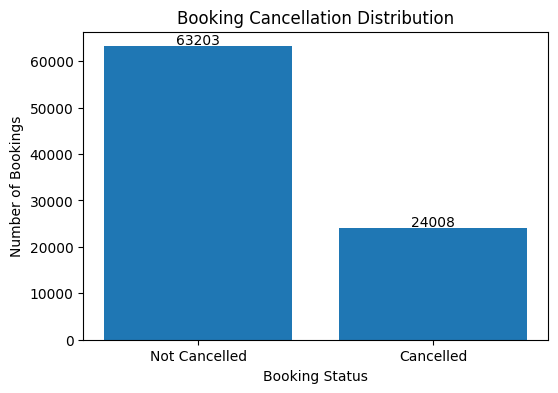

In [25]:
# Booking Cancellation Distribution
cancel_counts = df_clean["is_canceled"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(["Not Cancelled", "Cancelled"], cancel_counts.values)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
for i, value in enumerate(cancel_counts.values):
    plt.text(i, value + 500, str(value), ha='center')

plt.show()

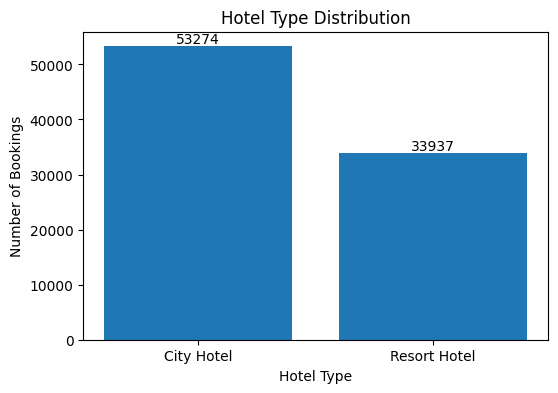

In [26]:
#hotel type distribution
hotel_counts = df_clean["hotel"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(hotel_counts.index, hotel_counts.values)
plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
for i, value in enumerate(hotel_counts.values):
    plt.text(i, value + 500, str(value), ha='center')
plt.show()

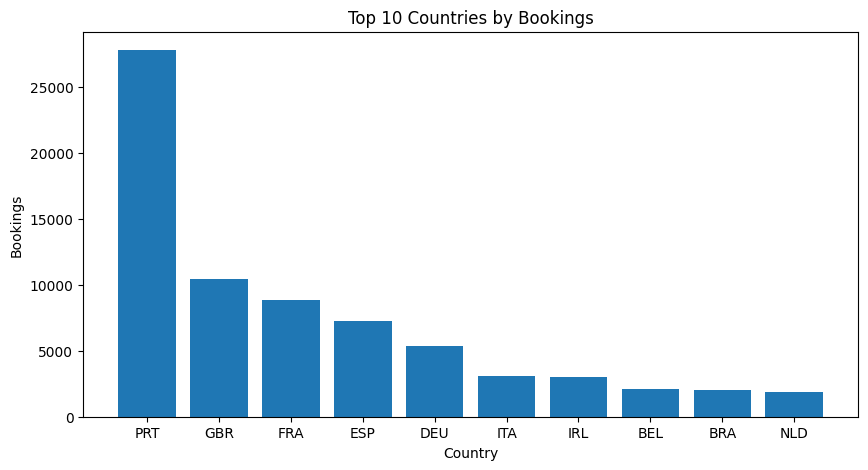

In [30]:
#Top 10 Countries by Bookings
top_countries = df_clean["country"].value_counts().head(10)
plt.figure(figsize=(10,5))
plt.bar(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Bookings")
plt.xlabel("Country")
plt.ylabel("Bookings")

plt.show()

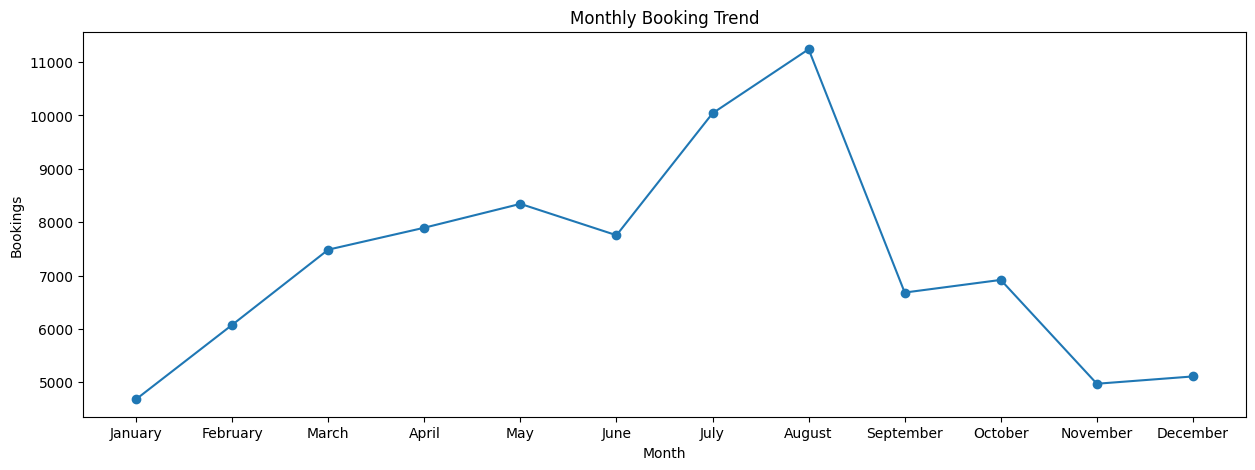

In [46]:
#Monthly Booking Trend
months = [
    "January","February","March","April","May","June",
 "July","August","September","October","November","December"
]

monthly = df_clean["arrival_date_month"].value_counts().reindex(months)
plt.figure(figsize=(15,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("Bookings")


plt.show()

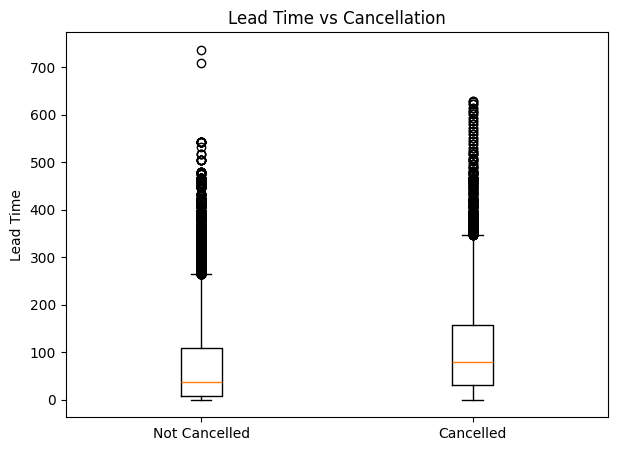

In [33]:
#lead time vs cancellation
plt.figure(figsize=(7,5))
plt.boxplot([
    df_clean[df_clean["is_canceled"]==0]["lead_time"],
    df_clean[df_clean["is_canceled"]==1]["lead_time"]
],
labels=["Not Cancelled","Cancelled"])
plt.title("Lead Time vs Cancellation")
plt.ylabel("Lead Time")

plt.show()

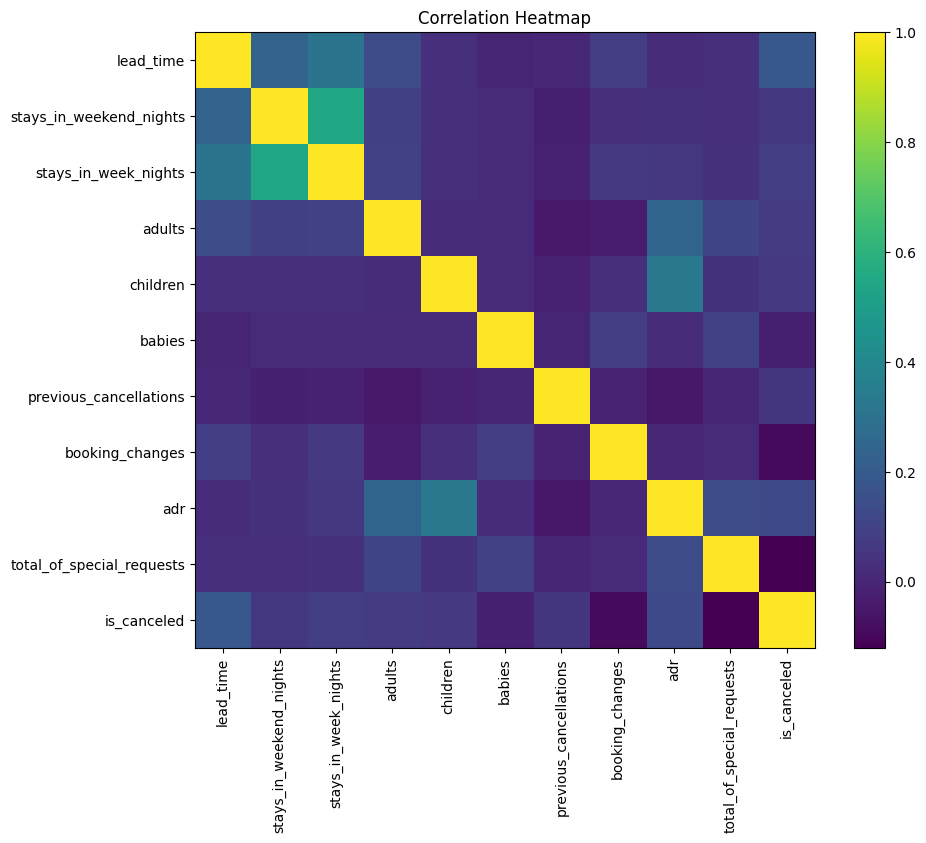

In [34]:
numeric_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "adr",
    "total_of_special_requests",
    "is_canceled"
]

corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

plt.show()

**feature engineering and data preprocessing**

In [35]:
df_clean.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [45]:
columns_to_drop = ["reservation_status","reservation_status_date"]
df_ml = df_clean.drop(columns=columns_to_drop)

print("Columns dropped successfully!")

Columns dropped successfully!


In [37]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
categorical_columns = df_ml.select_dtypes(include=["object"]).columns
for column in categorical_columns:
    df_ml[column] = label_encoder.fit_transform(df_ml[column])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [38]:
df_ml.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,1,0,342,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,3,0,0.0,0.0,0,2,0.0,0,0
1,1,0,737,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,4,0,0.0,0.0,0,2,0.0,0,0
2,1,0,7,2015,5,27,1,0,1,1,0.0,0,0,59,3,1,0,0,0,0,2,0,0,0.0,0.0,0,2,75.0,0,0
3,1,0,13,2015,5,27,1,0,1,1,0.0,0,0,59,2,0,0,0,0,0,0,0,0,304.0,0.0,0,2,75.0,0,0
4,1,0,14,2015,5,27,1,0,2,2,0.0,0,0,59,6,3,0,0,0,0,0,0,0,240.0,0.0,0,2,98.0,0,1


In [39]:
X = df_ml.drop("is_canceled", axis=1)
y = df_ml["is_canceled"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (87211, 29)
Target Shape: (87211,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,
random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (69768, 29)
Testing Set: (17443, 29)


In [41]:
#data scaling for logistic regresssion
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [42]:
print(type(X_train_scaled))
print(type(y_train))

print(X_train_scaled.shape)
print(X_test_scaled.shape)

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
(69768, 29)
(17443, 29)


**model bulding and evaluation**

In [47]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2),"%")

Logistic Regression Accuracy: 77.45 %


In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.79      0.93      0.86     12641
           1       0.66      0.37      0.47      4802

    accuracy                           0.77     17443
   macro avg       0.73      0.65      0.66     17443
weighted avg       0.76      0.77      0.75     17443



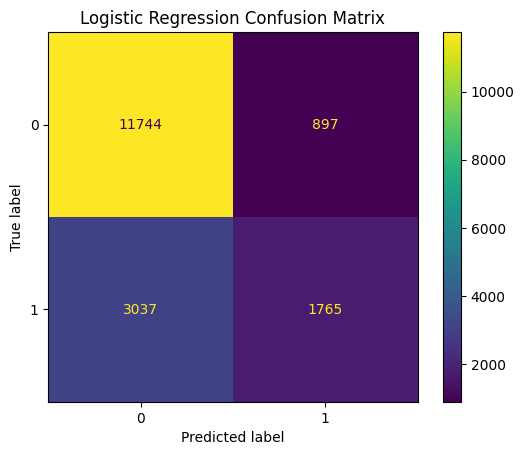

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [50]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2),"%")

Decision Tree Accuracy: 82.65 %


In [51]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88     12641
           1       0.71      0.62      0.66      4802

    accuracy                           0.83     17443
   macro avg       0.79      0.76      0.77     17443
weighted avg       0.82      0.83      0.82     17443



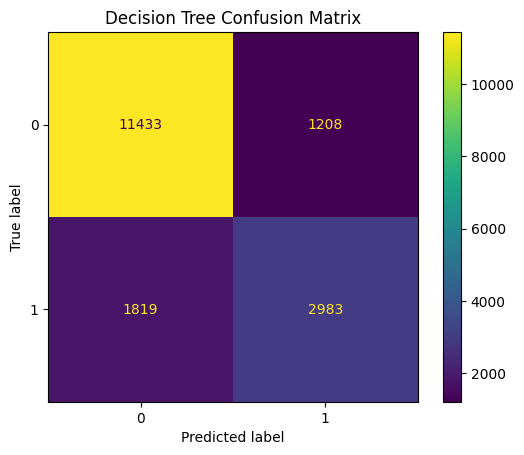

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_pred)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [55]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier( n_estimators=200,random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy*100,2),"%")

Random Forest Accuracy: 85.4 %


In [62]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90     12641
           1       0.77      0.66      0.71      4802

    accuracy                           0.85     17443
   macro avg       0.83      0.80      0.81     17443
weighted avg       0.85      0.85      0.85     17443



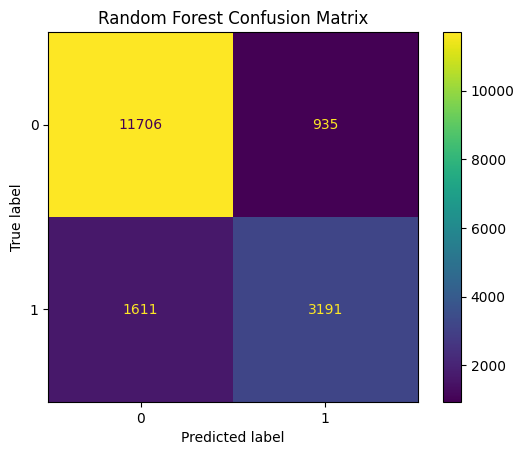

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [64]:
#kNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 79.73 %


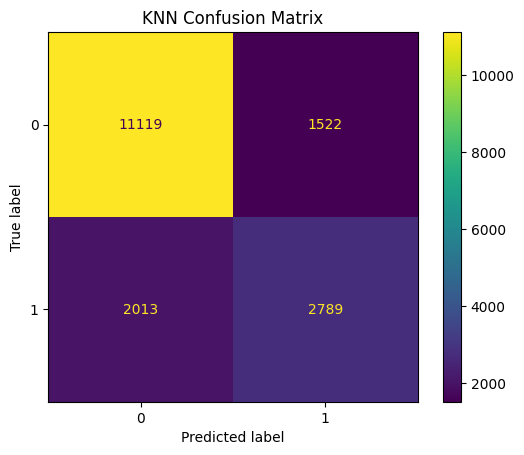

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

plt.title("KNN Confusion Matrix")

plt.show()

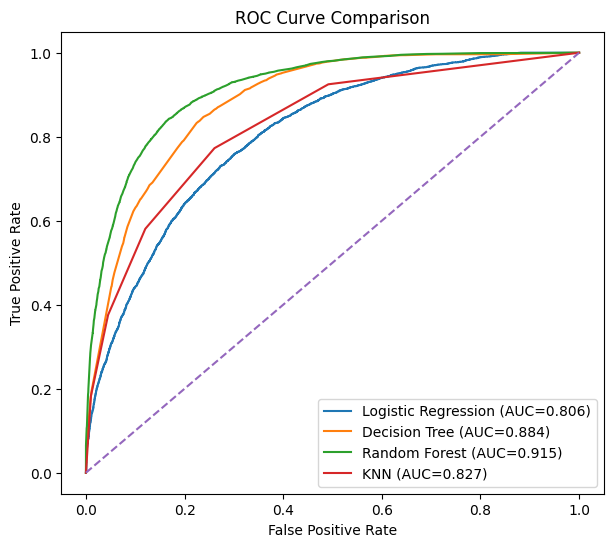

In [66]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(7,6))

# Logistic Regression
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]
fpr,tpr,_ = roc_curve(y_test,lr_prob)
plt.plot(fpr,tpr,label=f"Logistic Regression (AUC={auc(fpr,tpr):.3f})")

# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test,dt_prob)
plt.plot(fpr,tpr,label=f"Decision Tree (AUC={auc(fpr,tpr):.3f})")

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test,rf_prob)
plt.plot(fpr,tpr,label=f"Random Forest (AUC={auc(fpr,tpr):.3f})")

#kNN
# KNN
knn_prob = knn_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, knn_prob)
plt.plot(fpr, tpr, label=f"KNN (AUC={auc(fpr, tpr):.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [67]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

feature_importance

,Feature,Importance
1,lead_time,0.142981
12,country,0.104938
26,adr,0.095666
5,arrival_date_day_of_month,0.070957
4,arrival_date_week_number,0.065463
28,total_of_special_requests,0.059850
22,agent,0.059464
13,market_segment,0.046150
7,stays_in_week_nights,0.046094
3,arrival_date_month,0.035498


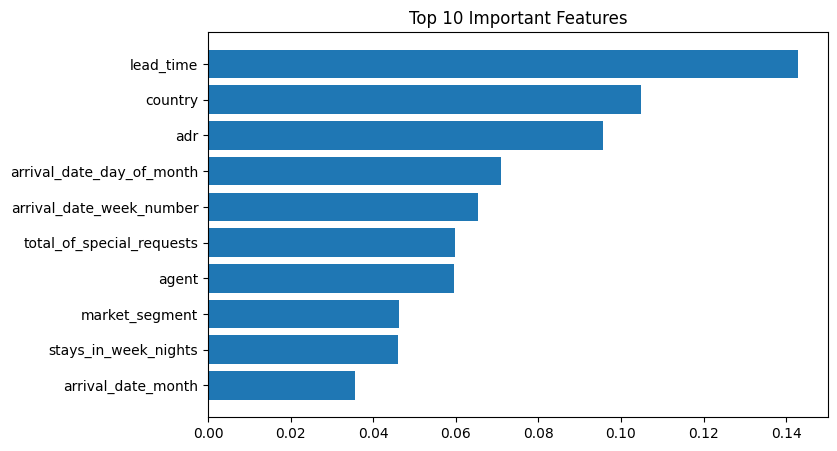

In [68]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [71]:
import joblib

joblib.dump(rf_model, "hotel_booking_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [72]:
from google.colab import files

files.download("hotel_booking_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>